# RISA Signal — EDA y comparación de modelos

CRISP-DM fase 2 (comprensión de datos) y fase 5 (Anomaly Model + Pattern Model), en formato notebook para lectura y
presentación. Este notebook **no implementa lógica nueva**: llama a las mismas funciones de `pipeline/` que corren en
producción (`pipeline.despliegue.load_or_build`, `pipeline.evaluacion.compare_models`) — así el notebook nunca puede
quedar desincronizado del pipeline real.

Mapeo completo de la arquitectura de negocio a estos módulos: [`pipeline/comprension_negocio.md`](../comprension_negocio.md).

Preguntas de negocio que este análisis responde:

1. ¿Qué tan completos y confiables llegan los datos de RISA Data V1.0?
2. Anomaly Model: ¿qué tan bien separa un enfoque estadístico/ML/DL ligero los casos inusuales de los esperados?
3. Pattern Model: ¿qué modelo entrenado generaliza mejor a un test nunca visto durante la selección?


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))  # repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from pipeline import despliegue, evaluacion
from pipeline.comprension_datos import load_raw_sources, profile_sources

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 110


## 1. Comprensión de los datos (fase 2)

Carga cruda de RISA Data V1.0 (`pipeline/data/raw/`) y perfilado — sin limpiar todavía.

In [2]:
raw = load_raw_sources()
report = profile_sources(raw)
pd.DataFrame(report).T[["rows", "patients_covered", "patient_coverage_pct"]]


,rows,patients_covered,patient_coverage_pct
patients,1000.0,1000.0,100.0
vital_signs,1622969,1000,100.0
laboratory_results,4593,1000,100.0
wearable_observations,895551,1000,100.0
device_observations,13329.0,1000.0,100.0
patient_context,8830.0,1000.0,100.0
conditions,1484.0,1000.0,100.0


### Calidad declarada por fuente (`quality_flag`)

No todo es `OK`: hay retransmisiones, variantes de unidad y señal baja — se tratan explícitamente en `preparacion_datos.py`, no se ignoran.

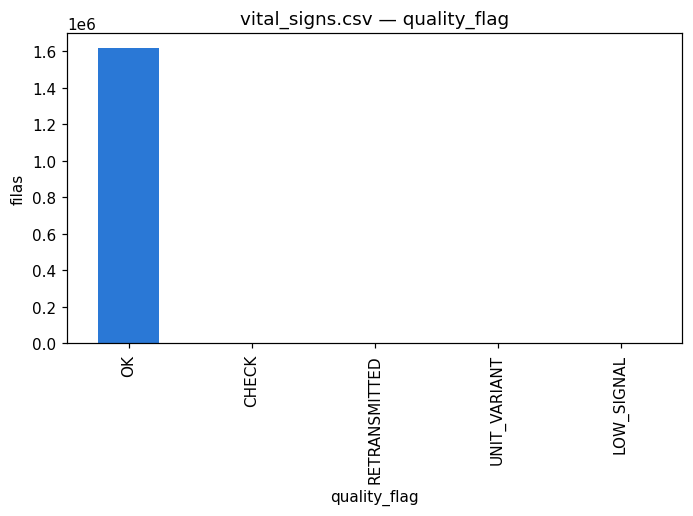

quality_flag
OK               1617991
CHECK               4164
RETRANSMITTED        540
UNIT_VARIANT         166
LOW_SIGNAL           108
Name: count, dtype: int64

In [3]:
vitals_quality = raw.vital_signs["quality_flag"].value_counts()
ax = vitals_quality.plot(kind="bar", title="vital_signs.csv — quality_flag", color="#2a78d6")
ax.set_ylabel("filas")
plt.tight_layout()
plt.show()
vitals_quality


### Distribución de variables vitales (crudo, sin normalizar)

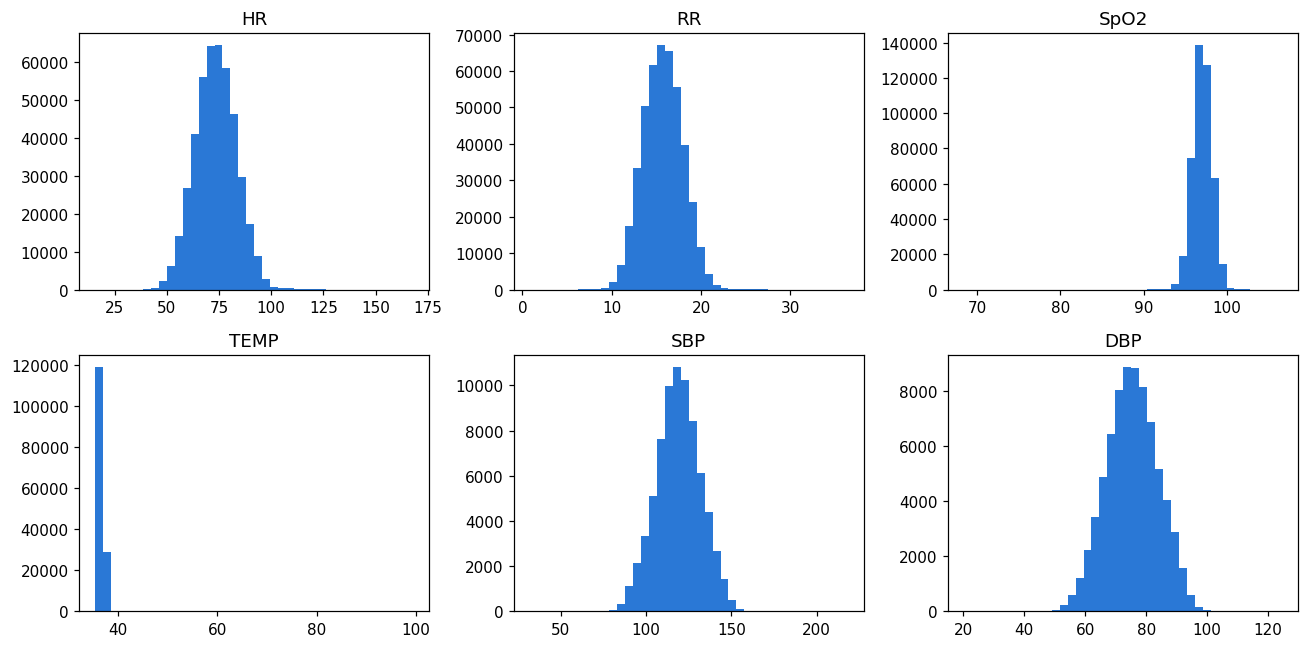

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
codes = ["HR", "RR", "SpO2", "TEMP", "SBP", "DBP"]
for ax, code_ in zip(axes.ravel(), codes):
    values = pd.to_numeric(raw.vital_signs.loc[raw.vital_signs["variable_code"] == code_, "value"], errors="coerce")
    ax.hist(values.dropna(), bins=40, color="#2a78d6")
    ax.set_title(code_)
plt.tight_layout()
plt.show()


## 2. Preparación + Modelado (fases 3-4)

`despliegue.load_or_build()` corre limpieza, normalización de unidad, pivote temporal, el Context Engine
(`motor_contexto.py`: actividad + sueño) y el motor de reglas (`modelado.py`, calibrado por percentil poblacional) —
todo lo que sirve el backend en producción.

In [5]:
result = despliegue.load_or_build()
print("Origen:", result.origin)
print("Pacientes:", len(result.patients))

levels = pd.Series([d.level for d in result.alert_drafts]).value_counts()
levels


Origen: RISA_DATA_V1.0
Pacientes: 1000


BAJO          554
DESCARTADO    413
MEDIO          27
ALTO            5
CRITICO         1
Name: count, dtype: int64

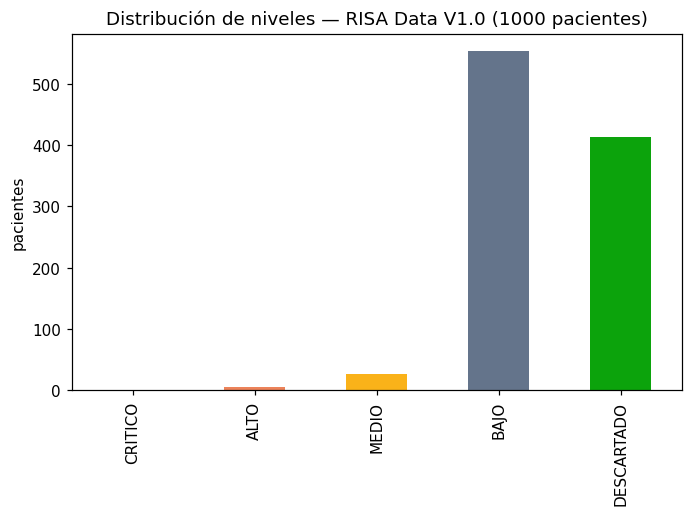

In [6]:
ax = levels.reindex(["CRITICO", "ALTO", "MEDIO", "BAJO", "DESCARTADO"]).plot(
    kind="bar", color=["#d03b3b", "#ec835a", "#fab219", "#64748b", "#0ca30c"]
)
ax.set_title("Distribución de niveles — RISA Data V1.0 (1000 pacientes)")
ax.set_ylabel("pacientes")
plt.tight_layout()
plt.show()


## 3. Evaluación: Anomaly Model + Pattern Model (fase 5)

Etiqueta débil (ver `ADR-0009`): positivo = patrón `PROGRESSIVE_MULTISOURCE` o `EARLY_SIGNAL` y no descartado.
Split por paciente 85 % (`dev`, validación cruzada de 5 folds — es la base de la selección) / 15 % (`test`, nunca
usado para elegir el modelo).

In [7]:
comparison = evaluacion.compare_models(result.alert_drafts)

def candidates_table(candidates):
    rows = []
    for name, splits in candidates.items():
        for split_name, m in splits.items():
            rows.append({"modelo": name, "split": split_name, "precision": m.precision, "recall": m.recall,
                         "f1": m.f1, "roc_auc": m.roc_auc, **{f"cm_{k}": v for k, v in m.confusion_matrix.items()}})
    return pd.DataFrame(rows).set_index(["modelo", "split"])

print("Anomaly Model elegido:", comparison.anomaly_chosen)
print("Pattern Model elegido:", comparison.pattern_chosen)


Anomaly Model elegido: mad
Pattern Model elegido: xgboost


### Anomaly Model — comparación completa

In [8]:
candidates_table(comparison.anomaly_candidates)

precision  recall     f1  roc_auc  cm_tp  cm_fp  \
modelo               split                                                    
zscore               cv         0.138   0.414  0.207    0.821     12     75   
                     test       0.235   1.000  0.381    0.959      4     13   
mad                  cv         0.154   0.483  0.233    0.735     14     77   
                     test       0.071   0.250  0.111    0.664      1     13   
iqr                  cv         0.098   0.310  0.149    0.724      9     83   
                     test       0.133   0.500  0.211    0.899      2     13   
isolation_forest     cv         0.135   0.414  0.203    0.807     12     77   
                     test       0.231   0.750  0.353    0.950      3     10   
local_outlier_factor cv         0.146   0.448  0.220    0.811     13     76   
                     test       0.188   0.750  0.300    0.957      3     13   
autoencoder_mlp      cv         0.132   0.414  0.200    0.743     12     79   
                     test       0.267   1.000  0.421    0.933      4     11   

                            cm_fn  cm_tn  
modelo               split                
zscore               cv        17    746  
                     test       0    133  
mad                  cv        15    744  
                     test       3    133  
iqr                  cv        20    738  
                     test       2    133  
isolation_forest     cv        17    744  
                     test       1    136  
local_outlier_factor cv        16    745  
                     test       1    133  
autoencoder_mlp      cv        17    742  
                     test       0    135

### Pattern Model — comparación completa

In [9]:
candidates_table(comparison.pattern_candidates)

precision  recall     f1  roc_auc  cm_tp  cm_fp  \
modelo              split                                                    
logistic_regression cv         0.182   0.759  0.293    0.919     22     99   
                    test       0.182   0.500  0.267    0.836      2      9   
random_forest       cv         0.500   0.034  0.065    0.950      1      1   
                    test       0.000   0.000  0.000    0.998      0      0   
xgboost             cv         0.538   0.483  0.509    0.965     14     12   
                    test       1.000   0.500  0.667    0.993      2      0   
lightgbm            cv         0.647   0.379  0.478    0.951     11      6   
                    test       1.000   0.250  0.400    0.991      1      0   

                           cm_fn  cm_tn  
modelo              split                
logistic_regression cv         7    722  
                    test       2    137  
random_forest       cv        28    820  
                    test       4    146  
xgboost             cv        15    809  
                    test       2    146  
lightgbm            cv        18    815  
                    test       3    146

### Matrices de confusión en test (nunca usado para elegir el modelo)

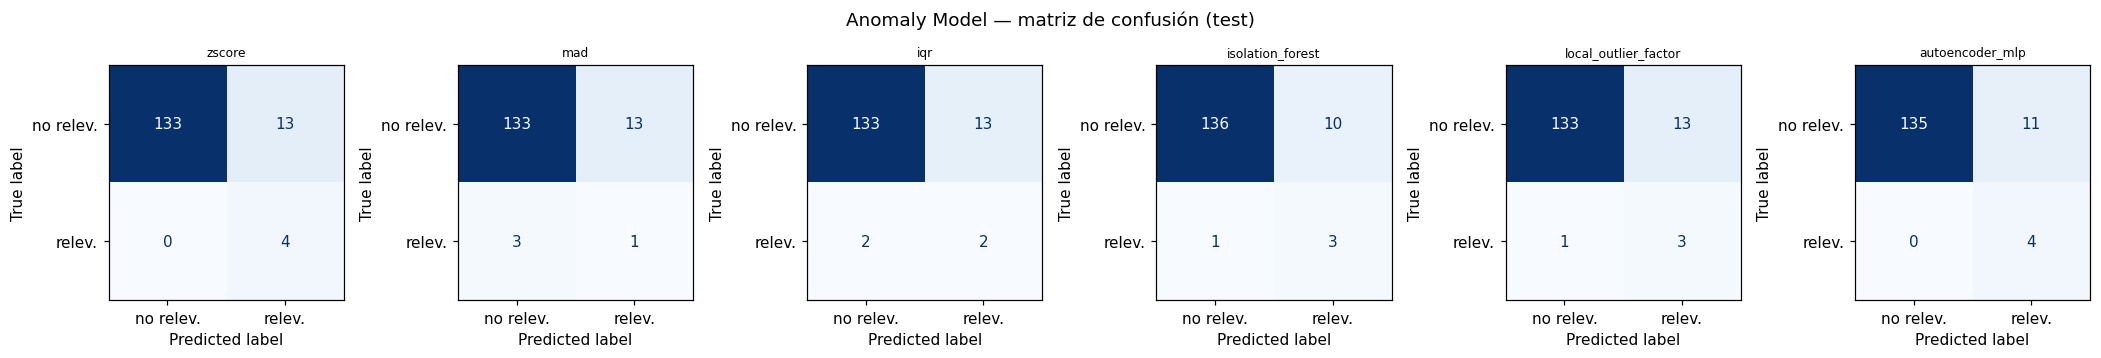

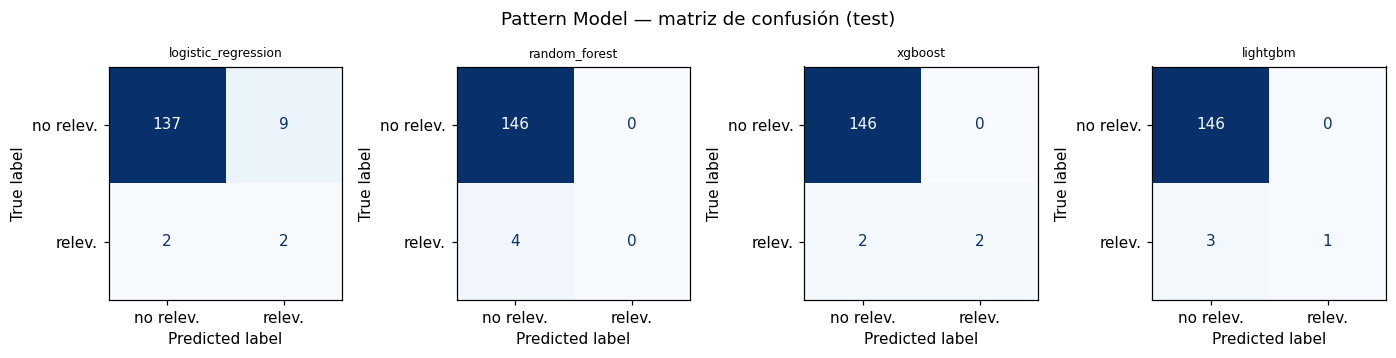

In [10]:
def plot_confusion(candidates, title):
    fig, axes = plt.subplots(1, len(candidates), figsize=(3.2 * len(candidates), 3.2))
    for ax, (name, splits) in zip(axes, candidates.items()):
        cm = splits["test"].confusion_matrix
        matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
        ConfusionMatrixDisplay(matrix, display_labels=["no relev.", "relev."]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_confusion(comparison.anomaly_candidates, "Anomaly Model — matriz de confusión (test)")
plot_confusion(comparison.pattern_candidates, "Pattern Model — matriz de confusión (test)")


### F1 por candidato — validación cruzada vs. test

El objetivo es visibilizar el sobreajuste: un modelo que gana en `cv` pero se desploma en `test` no generaliza (le pasó a `Random Forest` en el Pattern Model).

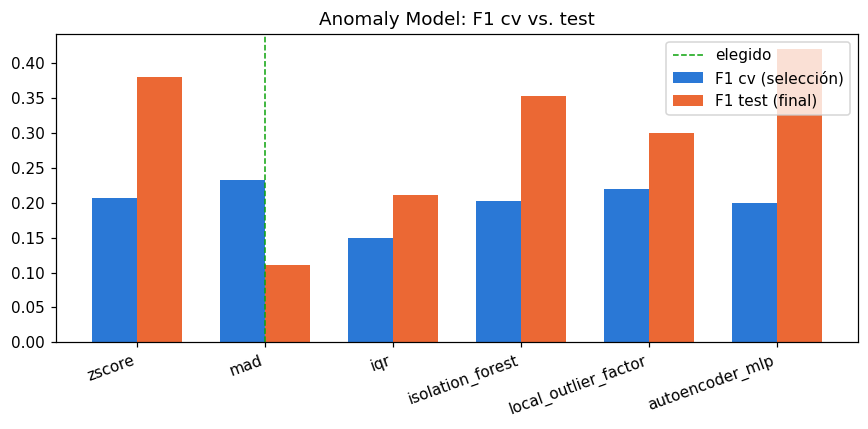

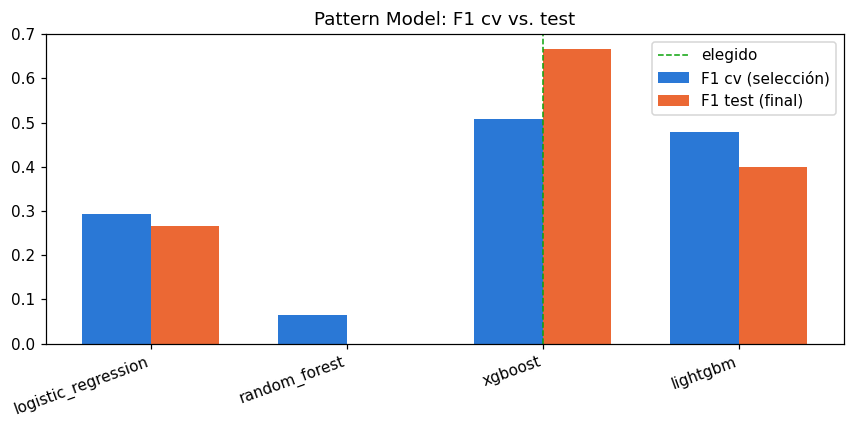

In [11]:
def plot_cv_vs_test(candidates, chosen, title):
    names = list(candidates.keys())
    cv_f1 = [candidates[n]["cv"].f1 for n in names]
    test_f1 = [candidates[n]["test"].f1 for n in names]
    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width / 2, cv_f1, width, label="F1 cv (selección)", color="#2a78d6")
    ax.bar(x + width / 2, test_f1, width, label="F1 test (final)", color="#eb6834")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.axvline(names.index(chosen), color="#0ca30c", linestyle="--", linewidth=1, label="elegido")
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_cv_vs_test(comparison.anomaly_candidates, comparison.anomaly_chosen, "Anomaly Model: F1 cv vs. test")
plot_cv_vs_test(comparison.pattern_candidates, comparison.pattern_chosen, "Pattern Model: F1 cv vs. test")


### Ambos modelos persistidos, recargados (sin reentrenar)

Esto es lo que hace el backend en producción: no vuelve a entrenar nada, carga los archivos .joblib ya elegidos en esta misma corrida.

In [12]:
(anomaly_model, anomaly_meta), (pattern_model, pattern_meta) = evaluacion.load_best_models()
print("Anomaly Model cargado desde disco:", anomaly_meta["chosen_model"], "== corrida actual:", anomaly_meta["chosen_model"] == comparison.anomaly_chosen)
print("Pattern Model cargado desde disco:", pattern_meta["chosen_model"], "== corrida actual:", pattern_meta["chosen_model"] == comparison.pattern_chosen)

sample_patient = result.patients["patient_id"].iloc[0]
from pipeline.evaluacion_comun import feature_matrix
X_sample, _ = feature_matrix(result.alert_drafts, [sample_patient])
pattern_proba = pattern_model.named_steps["model"].predict_proba(pattern_model.named_steps["scaler"].transform(X_sample))[:, 1][0]
print(f"pattern_score persistido para {sample_patient}: {pattern_proba:.3f}")


Anomaly Model cargado desde disco: mad == corrida actual: True
Pattern Model cargado desde disco: xgboost == corrida actual: True
pattern_score persistido para PAT-0001: 0.000


## 4. Conclusión

- El motor de **reglas dinámicas** (`modelado.py`) sigue siendo el que genera la evidencia trazable de cada alerta
  (`EvidenceItem`) — ningún modelo de la comparación la reemplaza, porque ninguno explica *por qué* de forma auditable
  registro por registro. Consulta al **Context Engine** (`motor_contexto.py`) para interpretar actividad y sueño.
- **Pattern Model**: `XGBoost` generalizó mejor que regresión logística, Random Forest y LightGBM (F1 test = 0.67,
  precisión perfecta) — se persiste y alimenta `pattern_score` en cada alerta.
- **Anomaly Model**: `MAD` ganó en validación cruzada, pero el autoencoder (`MLPRegressor`) y `Z-score` generalizaron
  mejor a test — se documenta así, sin forzar una narrativa más prolija de la que los datos sostienen. El ganador por
  el criterio de selección declarado (F1 en `cv`) es el que se persiste; la discrepancia con test es información, no
  se oculta (ver `ADR-0009`).
- `Random Forest` ganaba con un único split de validación (ver el histórico en `ADR-0009`), pero su F1 se desploma
  bajo validación cruzada de 5 folds — señal de sobreajuste sobre una muestra positiva pequeña (~3 % de 1000
  pacientes), no un error de implementación.
- **GRU/LSTM/Transformer** no se implementaron: con ~30 positivos en la etiqueta débil no hay datos suficientes para
  entrenar un modelo secuencial profundo sin que aprenda ruido — decisión documentada en
  `pipeline/comprension_negocio.md`, no una omisión.
- Ninguna de estas cifras es una afirmación de precisión clínica: son una comparación honesta entre enfoques, contra
  una etiqueta débil, porque RISA Data V1.0 no entrega Gold Standard (`ADR-0009`).